# A data-driven assessment of Continuum of Care (CoC) effectiveness in addressing homelessness among older adults (65+) in California

Methodology Overview:
1.  **Data Integration:** Load and integrate multiple datasets, including CoC
    geospatial data, census population figures, Zillow Home Value Index (ZHVI),
    and Point-in-Time (PIT) homelessness counts.
2.  **CoC Mapping:** Programmatically map each CoC to its constituent counties 
    and/or cities to enable accurate data aggregation.
3.  **Feature Engineering:** Construct the dependent and independent variables:
    - Dependent Variable: Count of homeless individuals aged 65+ in 2023.
    - Independent Variables: CoC population (and its log), population-weighted ZHVI,
      geographical coordinates (centroids), and a spatial lag term representing
      homelessness in neighboring CoCs.
4.  **Modeling and Evaluation:**
    - Analyze the impact of different feature combinations on model performance.
    - Compare the predictive accuracy of an ANCOVA (linear model) and a
      Random Forest Regressor.
5.  **Prediction Set Analysis:** Generate predictions on a synthetic dataset where
    population is held constant to isolate the effects of other variables.
6.  **Visualization:** Generate clean, paper-ready plots for results.Methodology Overview:
1.  **Data Integration:** Load and integrate multiple datasets, including CoC
    geospatial data, census population figures, Zillow Home Value Index (ZHVI),
    and Point-in-Time (PIT) homelessness counts.
2.  **CoC Mapping:** Programmatically map each CoC to its constituent counties 
    and/or cities to enable accurate data aggregation.
3.  **Feature Engineering:** Construct the dependent and independent variables:
    - Dependent Variable: Count of homeless individuals aged 65+ in 2023.
    - Independent Variables: CoC population (and its log), population-weighted ZHVI,
      geographical coordinates (centroids), and a spatial lag term representing
      homelessness in neighboring CoCs.
4.  **Modeling and Evaluation:**
    - Analyze the impact of different feature combinations on model performance.
    - Compare the predictive accuracy of an ANCOVA (linear model) and a
      Random Forest Regressor.
5.  **Visualization:** Generate clean, paper-ready plots for results.

## 1. Setup and Imports

In [1]:
import os
import re
from itertools import combinations
import numpy as np
import pandas as pd
import geopandas as gpd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Configure plot style for publications
sns.set_context("paper", font_scale=1.2)
sns.set_style("whitegrid")

## 2. Data Loading and Initial Cleaning

In [3]:
# Define file paths
DATA_DIR = "data"
COC_SHAPEFILE_DIR = os.path.join(DATA_DIR, "California")
COUNTY_ZHVI_PATH = os.path.join(DATA_DIR, "County_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv")
CITY_ZHVI_PATH = os.path.join(DATA_DIR, "City_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv")
CENSUS_PATH = os.path.join(DATA_DIR, "census-ca-2020-2024.csv")
PIT_COUNT_PATH = os.path.join(DATA_DIR, "cy_age.csv")

In [4]:
# Load Datasets
county_zhvi_df = pd.read_csv(COUNTY_ZHVI_PATH)
city_zhvi_df = pd.read_csv(CITY_ZHVI_PATH)
census_df = pd.read_csv(CENSUS_PATH)
pit_df = pd.read_csv(
    PIT_COUNT_PATH,
    na_values="*",
    dtype={
        "AGE_GROUP_PUBLIC": pd.CategoricalDtype(
            categories=[
                "Under 18",
                "18-24",
                "25-34",
                "35-44",
                "45-54",
                "55-64",
                "65+",
                # Ignore Unknown and Invalid categories
                # "Unknown",
                # "Invalid",
            ],
            ordered=True,
        ),
    },
).dropna()

# Load and concatenate all CoC shapefiles
shapefile_paths = [
    os.path.join(COC_SHAPEFILE_DIR, f, f"{f}.shp")
    for f in os.listdir(COC_SHAPEFILE_DIR)
    if f.startswith("CA_")
]
coc_gdf = pd.concat([gpd.read_file(shp) for shp in shapefile_paths], ignore_index=True)

In [5]:
def clean_name(name):
    """
    Standardize CoC names from different sources to either:
    - a comma-separated list of counties
    - a county name
    - a city name
    """
    name = name.replace(' CoC', '')
    name = name.replace(' City & County/', ', ')
    name = re.sub(r'[^/]*\/', '', name) # strip redundant city lists before a slash
    name = name.replace('City & County', '').replace('City and County', '').strip()
    name = name.replace('(Los Angeles)', '').replace('(Los Angeles County)', '').strip()
    return name.replace(' County', '').replace(' Counties', '').replace(' City', '').strip()

In [6]:
# Clean Point-in-Time (PIT) data
pit_df.rename(columns={
    'CALENDAR_YEAR': 'Year',
    'LOCATION': 'CoC_Name',
    'AGE_GROUP_PUBLIC': 'Age',
    'EXPERIENCING_HOMELESSNESS_CNT': 'Homeless count'
}, inplace=True)
pit_df['CoC_Name'] = pit_df['CoC_Name'].apply(clean_name)

Use _geography_ for either city or county.

In [7]:
# Clean Census data
census_df.rename(columns={'County': 'Geography'}, inplace=True)
census_df['Geography'] = census_df['Geography'].apply(clean_name)

In [8]:
# Clean Zillow Home Value Index (ZHVI) data
county_zhvi_df['RegionName'] = county_zhvi_df['RegionName'].apply(clean_name)
city_zhvi_df['RegionName'] = city_zhvi_df['RegionName'].apply(clean_name)

In [9]:
# Clean and standardize CoC GeoDataFrame
coc_gdf.rename(columns={'COCNAME': 'CoC_Name'}, inplace=True)
coc_gdf['CoC_Name'] = coc_gdf['CoC_Name'].apply(clean_name)

## 3. CoC to Geography Mapping and Population Aggregation (Paper Sections 2.1, 2.2.1)

In [10]:
# Get a list of all counties in California from the census data
ca_counties = set(census_df['Geography'])

In [11]:
def get_geographies_from_coc(coc_name):
    """
    Parses a CoC name to extract constituent geographies (counties or cities).
    """
    geographies = []
    
    # Split by common delimiters for multi-geography CoCs
    potential_geos = re.split(r', | and ', clean_name(coc_name))
    
    for geo in potential_geos:
        if geo: # Ensure we don't add empty strings
            geo_type = 'County' if geo in ca_counties else 'City'
            geographies.append({'Geography': geo, 'Type': geo_type})
    return geographies

In [12]:
# Create a long-format DataFrame mapping each CoC to its constituent geographies
coc_geo_map_list = []
for _, row in coc_gdf.iterrows():
    geos = get_geographies_from_coc(row['CoC_Name'])
    for geo_info in geos:
        coc_geo_map_list.append({
            'CoC_Name': row['CoC_Name'],
            'Geography': geo_info['Geography'],
            'Type': geo_info['Type']
        })
coc_geo_map = pd.DataFrame(coc_geo_map_list).drop_duplicates().reset_index(drop=True)

In [13]:
# Aggregate Population Data to CoC Level
# Note: City populations are not in census_df, so we only join on counties.
coc_pop = pd.merge(coc_geo_map[coc_geo_map['Type'] == 'County'], census_df, on='Geography', how='left')
coc_population_df = coc_pop.groupby('CoC_Name')[[str(year) for year in range(2020, 2024)]].sum().reset_index()
coc_pop.drop(columns=['Type', 'Base'], inplace=True)
coc_map = coc_pop.melt(id_vars=['CoC_Name', 'Geography'], var_name='Year', value_name='Population')
coc_map['Year'] = pd.to_numeric(coc_map.Year, errors='coerce')
coc_population_df = coc_population_df.melt(id_vars=['CoC_Name'], var_name='Year', value_name='Population')
coc_population_df['Year'] = pd.to_numeric(coc_population_df.Year, errors='coerce')

In [14]:
# Source: ACS 1/5-Year Estimates Detailed Tables
city_coc_population_df = pd.DataFrame(
    columns=['CoC_Name', 'Year', 'Population'],
    data=[
        ['Glendale',   2020, 199357],
        ['Glendale',   2021, 196512],
        ['Glendale',   2022, 194512],
        ['Glendale',   2023, 192270],
        ['Long Beach', 2020, 462081],
        ['Long Beach', 2021, 466565],
        ['Long Beach', 2022, 462293],
        ['Long Beach', 2023, 458491],
        ['Pasadena',   2020, 273328],
        ['Pasadena',   2021, 271732],
        ['Pasadena',   2022, 268832],
        ['Pasadena',   2023, 266090],
    ],
)

In [15]:
coc_population_df = pd.concat((coc_population_df, city_coc_population_df))

# Subtract LA's city-level CoCs population from LA's county-wide CoC
coc_population_df.loc[coc_population_df.CoC_Name == 'Los Angeles', 'Population'] = \
    coc_population_df.loc[coc_population_df.CoC_Name == 'Los Angeles', 'Population'] \
    - coc_population_df.loc[coc_population_df.CoC_Name == "Glendale", 'Population'].to_numpy() \
    - coc_population_df.loc[coc_population_df.CoC_Name == "Long Beach", 'Population'].to_numpy() \
    - coc_population_df.loc[coc_population_df.CoC_Name == "Pasadena", 'Population'].to_numpy()

In [16]:
city_coc_population_df['Geography'] = city_coc_population_df['CoC_Name']
coc_map = pd.concat((coc_map, city_coc_population_df))

## 4. Feature Engineering (Paper Section 2.2)

### 4.1 Dependent Variable: Homelessness Count

Especially want to predict for age group 65+ in 2023

In [17]:
homelessness_df = pit_df[
    (pit_df["Year"] >= 2020)
    & (pit_df["Year"] <= 2023)
    & (pit_df["CoC_Name"] != "California")
    & (pit_df["Age"] != "Invalid")
    & (pit_df["Age"] != "Unknown")
]
homelessness_df = homelessness_df[["CoC_Name", "Year", "Age", "Homeless count"]]

### 4.2 Independent Variables

In [18]:
# --- Housing Price Data (ZHVI - Section 2.2.2) ---
def get_mean_zhvi_for_year(zhvi_df, year):
    """Extracts and calculates the mean ZHVI for a given year."""
    year_cols = [c for c in zhvi_df.columns if c.startswith(str(year))]
    if not year_cols:
        return pd.DataFrame(columns=['Geography', 'ZHVI'])
    
    zhvi_year = zhvi_df[['RegionName'] + year_cols]
    zhvi_year_melted = zhvi_year.melt(id_vars='RegionName', value_vars=year_cols, value_name='ZHVI')
    mean_zhvi = zhvi_year_melted.groupby('RegionName')['ZHVI'].mean().reset_index()
    return mean_zhvi.rename(columns={'RegionName': 'Geography'})

In [19]:
county_zhvi_df = county_zhvi_df[county_zhvi_df.State=="CA"]
city_zhvi_df = city_zhvi_df[city_zhvi_df.State=="CA"]
city_zhvi_df = city_zhvi_df[(city_zhvi_df.RegionName=="Glendale")|(city_zhvi_df.RegionName=="Long Beach")|(city_zhvi_df.RegionName=="Pasadena")]

In [20]:
zhvi_dfs = []
for year in range(2020, 2024):
    zhvi_county = get_mean_zhvi_for_year(county_zhvi_df, year)
    zhvi_city = get_mean_zhvi_for_year(city_zhvi_df, year)
    zhvi_full = pd.concat([zhvi_county, zhvi_city]).dropna()
    zhvi_full['Year'] = year
    zhvi_dfs.append(zhvi_full)
zhvi_df = pd.concat(zhvi_dfs)

In [21]:
merged_geo_zhvi = pd.merge(coc_geo_map, zhvi_df, on='Geography', how='inner')
merged_abc = pd.merge(merged_geo_zhvi, coc_map, on=['CoC_Name', 'Geography', 'Year'], how='inner')
merged_abc['Numerator'] = merged_abc['Population'] * merged_abc['ZHVI']
grouped_data = merged_abc.groupby(['CoC_Name', 'Year']).agg(
    total_numerator=('Numerator', 'sum'),
    total_denominator=('ZHVI', 'sum')
).reset_index()
grouped_data['Housing cost'] = grouped_data['total_numerator'] / grouped_data['total_denominator']
coc_zhvi_df = grouped_data[['CoC_Name', 'Year', 'Housing cost']]

In [22]:
# --- Geographical Features (Section 2.2.3) ---
# Adjacency Graph
coc_gdf_proj = coc_gdf.to_crs(epsg=3310)  # Project for accurate touches
adjacency = {row.CoC_Name: [] for _, row in coc_gdf_proj.iterrows()}
for index, coc in coc_gdf_proj.iterrows():
    neighbors = coc_gdf_proj[
        coc_gdf_proj.geometry.touches(coc.geometry)
    ].CoC_Name.tolist()
    adjacency[coc.CoC_Name].extend(neighbors)
adjacency_df = pd.DataFrame(
    [
        (name, neighbor)
        for name, neighbors in adjacency.items()
        for neighbor in neighbors
    ],
    columns=["CoC_Name", "Neighbor"],
)

In [23]:
# Centroids (Latitude and Longitude) - calculated on projected CRS, then converted to WGS84
centroids_proj = coc_gdf_proj.geometry.centroid
centroids_wgs84 = centroids_proj.to_crs(epsg=4326)
coc_gdf['Longitude'] = centroids_wgs84.x
coc_gdf['Latitude'] = centroids_wgs84.y

In [24]:
# Spatial Lag
df_neighbor_counts = pd.merge(
    pd.merge(homelessness_df, adjacency_df, on="CoC_Name"),
    homelessness_df.rename(
        columns={"CoC_Name": "Neighbor", "Homeless count": "NeighborCount"}
    ),
    on=["Neighbor", "Year", "Age"],
    how="left",
)
spatial_lag_df = (
    df_neighbor_counts.groupby(["CoC_Name", "Year", "Age"], observed=True)
    .agg(SpatialLag=("NeighborCount", "mean"))
    .reset_index()
    .rename(columns={"SpatialLag": "Spatial lag"})
)

In [25]:
# ## 5. Final DataFrame Assembly
final_df = pd.merge(homelessness_df, coc_population_df, on=['CoC_Name', 'Year'], how='inner')
final_df = pd.merge(final_df, coc_zhvi_df, on=['CoC_Name', 'Year'], how='inner')
final_df = pd.merge(final_df, coc_gdf[['CoC_Name', 'Latitude', 'Longitude']], on='CoC_Name', how='inner')
final_df = pd.merge(final_df, spatial_lag_df, on=['CoC_Name', 'Year', 'Age'], how='inner')
final_df

,CoC_Name,Year,Age,Homeless count,Population,Housing cost,Latitude,Longitude,Spatial lag
0,Santa Clara,2020,18-24,831.0,1924802,1924802.0,37.231452,-121.694269,331.166667
1,Santa Clara,2020,25-34,1729.0,1924802,1924802.0,37.231452,-121.694269,636.833333
2,Santa Clara,2020,35-44,1863.0,1924802,1924802.0,37.231452,-121.694269,642.166667
3,Santa Clara,2020,45-54,1758.0,1924802,1924802.0,37.231452,-121.694269,583.000000
4,Santa Clara,2020,55-64,1880.0,1924802,1924802.0,37.231452,-121.694269,623.000000
...,...,...,...,...,...,...,...,...,...
1220,San Luis Obispo,2023,35-44,564.0,282007,282007.0,35.387191,-120.402481,964.000000
1221,San Luis Obispo,2023,45-54,438.0,282007,282007.0,35.387191,-120.402481,735.250000
1222,San Luis Obispo,2023,55-64,351.0,282007,282007.0,35.387191,-120.402481,657.750000
1223,San Luis Obispo,2023,65+,219.0,282007,282007.0,35.387191,-120.402481,301.750000


In [26]:
# Add log of population
final_df['log(Population)'] = np.log(final_df['Population'])

In [27]:
# Clean up and set index
final_df.dropna(inplace=True)
final_df.set_index('CoC_Name', inplace=True)

Final clean DataFrame for modeling

In [28]:
final_df

,Year,Age,Homeless count,Population,Housing cost,Latitude,Longitude,Spatial lag,log(Population)
CoC_Name,,,,,,,,,
Santa Clara,2020,18-24,831.0,1924802,1924802.0,37.231452,-121.694269,331.166667,14.470334
Santa Clara,2020,25-34,1729.0,1924802,1924802.0,37.231452,-121.694269,636.833333,14.470334
Santa Clara,2020,35-44,1863.0,1924802,1924802.0,37.231452,-121.694269,642.166667,14.470334
Santa Clara,2020,45-54,1758.0,1924802,1924802.0,37.231452,-121.694269,583.000000,14.470334
Santa Clara,2020,55-64,1880.0,1924802,1924802.0,37.231452,-121.694269,623.000000,14.470334
...,...,...,...,...,...,...,...,...,...
San Luis Obispo,2023,35-44,564.0,282007,282007.0,35.387191,-120.402481,964.000000,12.549687
San Luis Obispo,2023,45-54,438.0,282007,282007.0,35.387191,-120.402481,735.250000,12.549687
San Luis Obispo,2023,55-64,351.0,282007,282007.0,35.387191,-120.402481,657.750000,12.549687


In [29]:
final_df = final_df.reset_index()

## 6. Modeling and Evaluation (Paper Section 2.3)

In [30]:
# Define features and target
TARGET = 'Homeless count'
FEATURES = ['Population', 'log(Population)', 'Housing cost', 'Latitude', 'Longitude', 'Spatial lag']
X = final_df[FEATURES]
y = final_df[TARGET]

### 6.1 Feature Combination Analysis

In [31]:
X = pd.get_dummies(final_df[["Year", "Age"] + FEATURES], columns=['Age'], prefix='Age')

In [32]:
rmse_results = {}
for i in range(1, len(FEATURES) + 1):
    for combo in combinations(FEATURES, i):
        if 'Population' in combo and 'log(Population)' in combo:
            continue
        combo_list = list(combo)
        X_combo = X[combo_list+['Year']+[f'Age_{group}' for group in final_df.Age.unique()]]
        
        num_experiments = 100
        total_rmse = 0
        for i in range(num_experiments):
            X_train, X_test, y_train, y_test = train_test_split(X_combo, y, test_size=0.2, random_state=i)
            
            model = RandomForestRegressor(n_estimators=100, random_state=i, oob_score=True)
            model.fit(X_train, y_train)

            preds = model.predict(X_test)
            total_rmse += np.sqrt(mean_squared_error(y_test, preds))

        rmse = total_rmse / num_experiments
        rmse_results[combo] = rmse

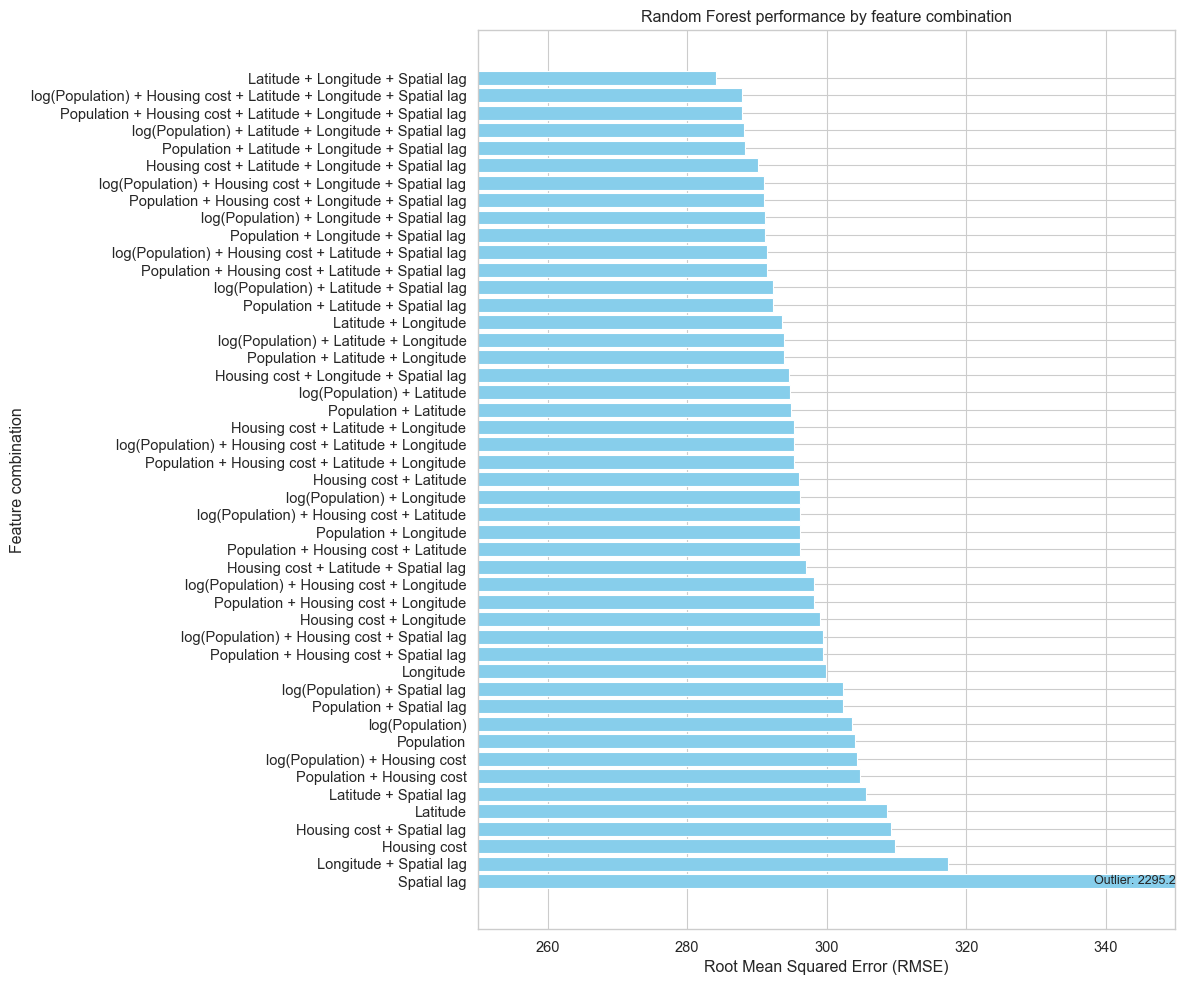

In [33]:
# Plotting RMSE results
plt.figure(figsize=(12, 10))
sorted_results = sorted(rmse_results.items(), key=lambda item: item[1], reverse=True)
combo_labels = [' + '.join(c) for c, _ in sorted_results]
rmse_values = [r for _, r in sorted_results]
plt.barh(combo_labels, rmse_values, color='skyblue')
plt.xlim((250, 350))
plt.text(350, 0, f"Outlier: {rmse_results[('Spatial lag',)]:.1f}", va='center', ha='right', fontsize=9)
plt.xlabel('Root Mean Squared Error (RMSE)')
plt.ylabel('Feature combination')
plt.title('Random Forest performance by feature combination')
plt.tight_layout()
plt.show()

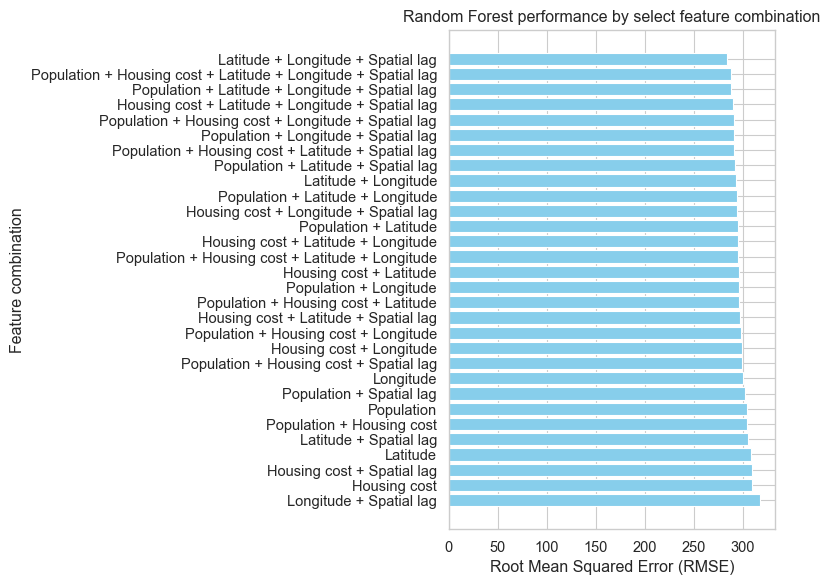

In [34]:
# Plotting RMSE results
plt.figure(figsize=(8, 6))
sorted_results = sorted(
    filter(
        lambda item: item[1] < 500 and "log(Population)" not in item[0],
        rmse_results.items(),
    ),
    key=lambda item: item[1],
    reverse=True,
)
combo_labels = [" + ".join(c) for c, _ in sorted_results]
rmse_values = [r for _, r in sorted_results]
plt.barh(combo_labels, rmse_values, color="skyblue")
# plt.xlim((88, 96))
plt.xlabel("Root Mean Squared Error (RMSE)")
plt.ylabel("Feature combination")
plt.title("Random Forest performance by select feature combination")
plt.tight_layout()
plt.show()

In [ ]:
ancova_rmse_results = {}
for i in range(1, len(FEATURES) + 1):
    for combo in combinations(FEATURES, i):
        if "Population" in combo and "log(Population)" in combo:
            continue
        combo_list = list(combo)
        X_combo = final_df[combo_list + ["Year", "Age"]]

        num_experiments = 10
        total_rmse = 0
        for j in range(num_experiments):
            X_train, X_test, y_train, y_test = train_test_split(
                X_combo, y, test_size=0.2, random_state=i + 100 * j
            )

            formula = f'Q("Homeless count") ~ Year + C(Age) + {' + '.join([f'Q("{feature}")' for feature in combo])}'
            model = smf.ols(formula, data=final_df).fit()

            preds = model.predict(X_test)
            total_rmse += np.sqrt(mean_squared_error(y_test, preds))

        rmse = total_rmse / num_experiments
        ancova_rmse_results[(combo,())] = rmse

        if len(combo) > 1:
            for cross in combinations(combo, 2):
                num_experiments = 10
                total_rmse = 0
                for j in range(num_experiments):
                    X_train, X_test, y_train, y_test = train_test_split(
                        X_combo, y, test_size=0.2, random_state=i + 100 * j
                    )

                    formula = f'Q("Homeless count") ~ Year + C(Age) + {
                        ' + '.join([f'Q("{feature}")' for feature in combo])
                    } + {' : '.join([f'Q("{feature}")' for feature in cross])}'
                    model = smf.ols(formula, data=final_df).fit()

                    preds = model.predict(X_test)
                    total_rmse += np.sqrt(mean_squared_error(y_test, preds))

                rmse = total_rmse / num_experiments
                ancova_rmse_results[(combo, cross)] = rmse

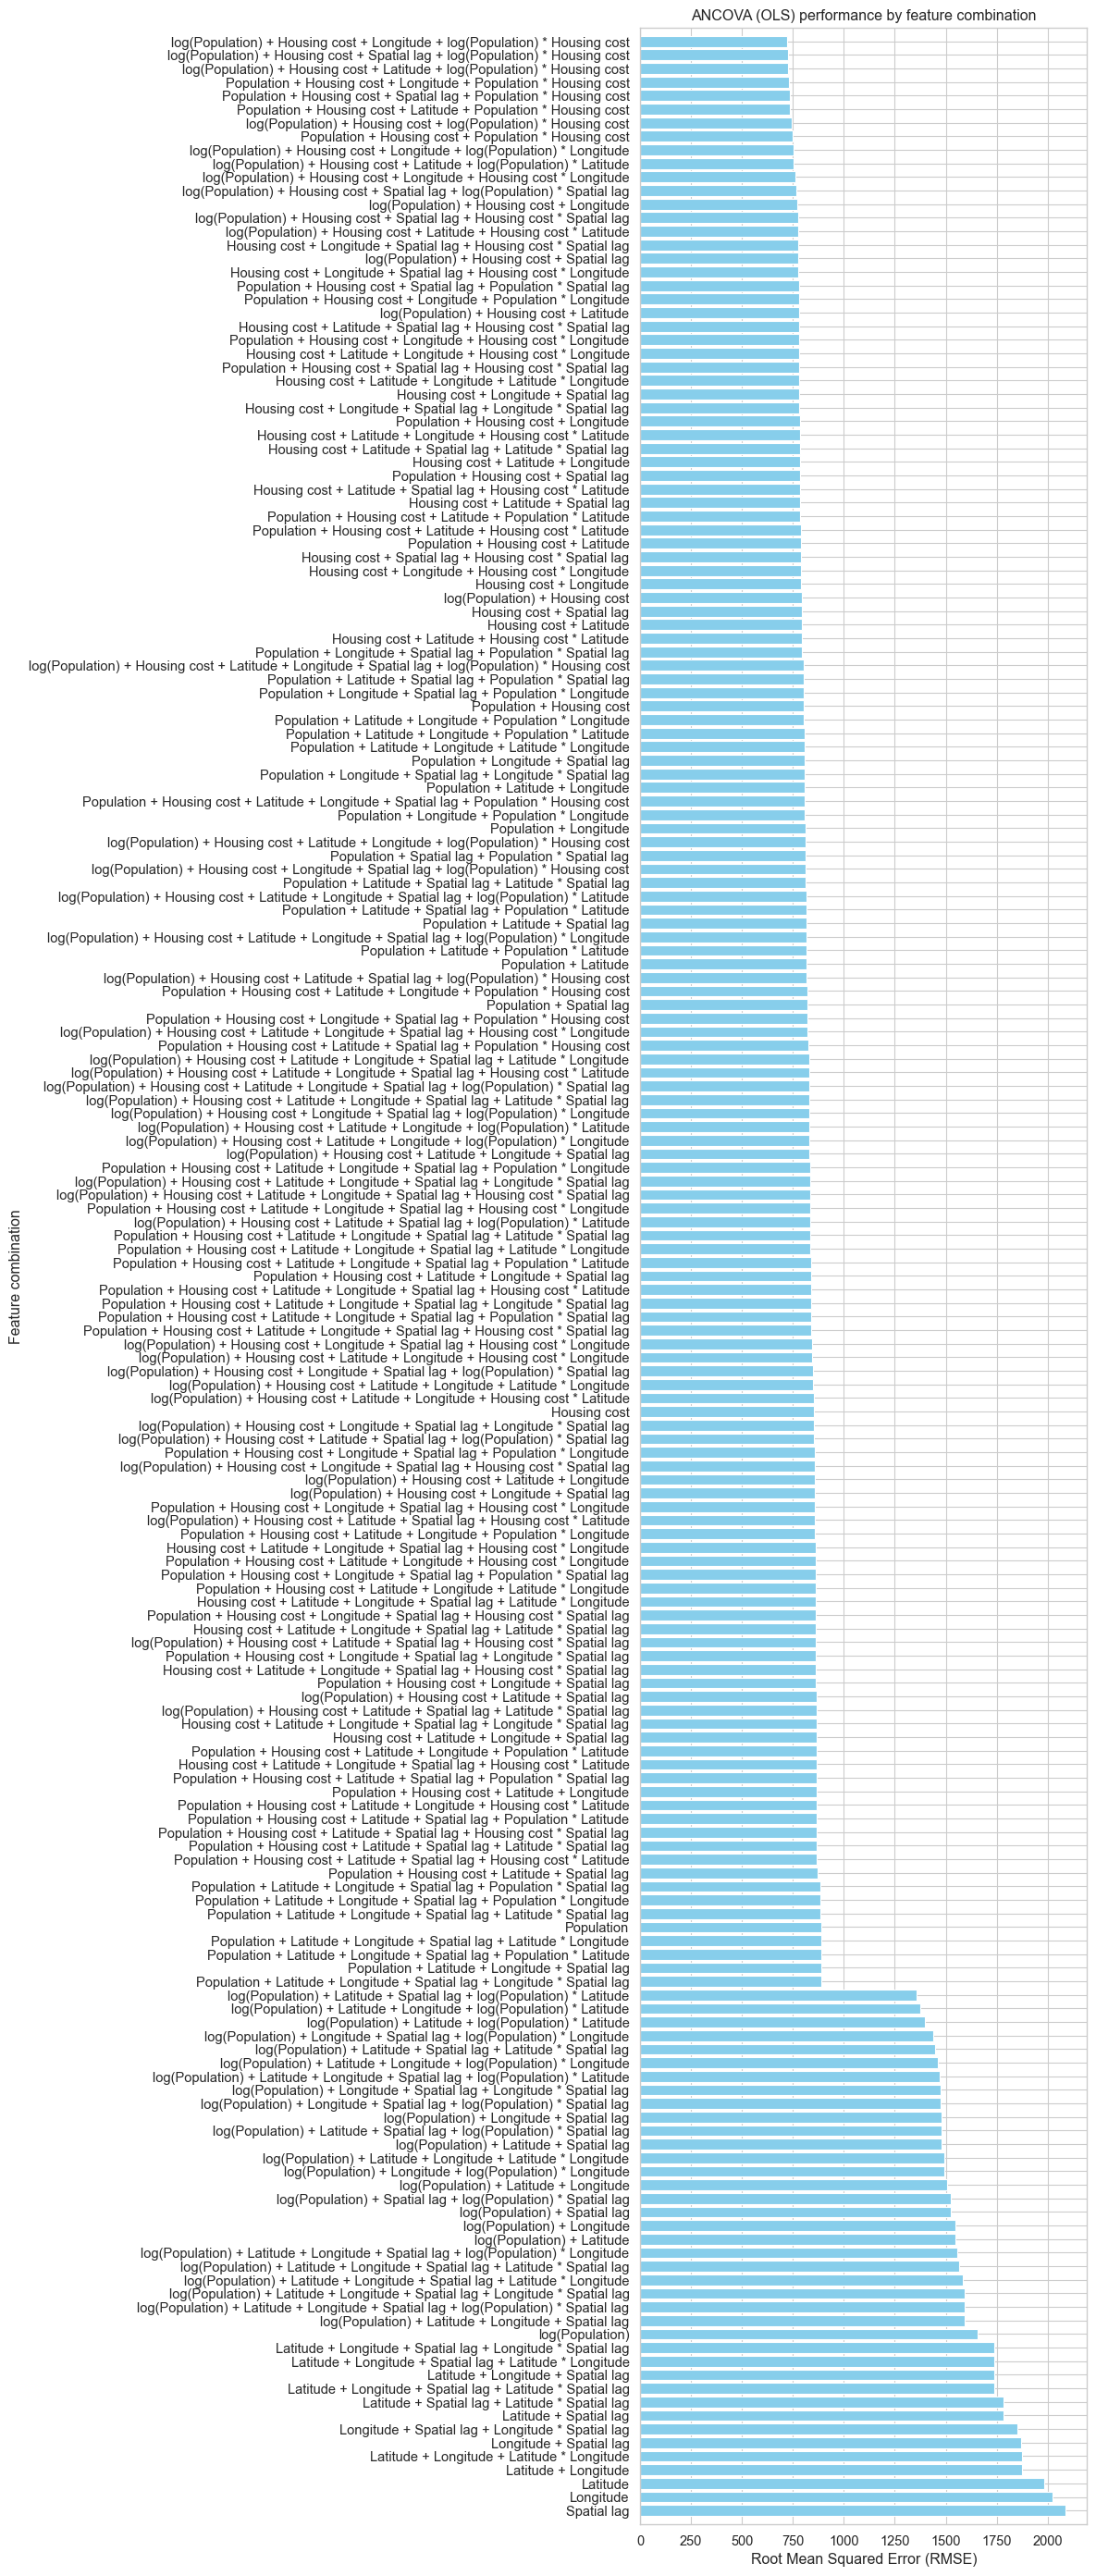

In [87]:
# Plotting ANCOVA RMSE results
plt.figure(figsize=(12, 28))
sorted_results = sorted(ancova_rmse_results.items(), key=lambda item: item[1], reverse=True)
combo_labels = [f"{' + '.join(combo)} + {' * '.join(cross)}" if len(cross) > 0 else ' + '.join(combo) for (combo, cross), _ in sorted_results]
rmse_values = [r for _, r in sorted_results]
plt.barh(combo_labels, rmse_values, color='skyblue')
plt.ylim([-1, len(rmse_values)])
plt.xlabel('Root Mean Squared Error (RMSE)')
plt.ylabel('Feature combination')
plt.title('ANCOVA (OLS) performance by feature combination')
plt.tight_layout()
plt.show()

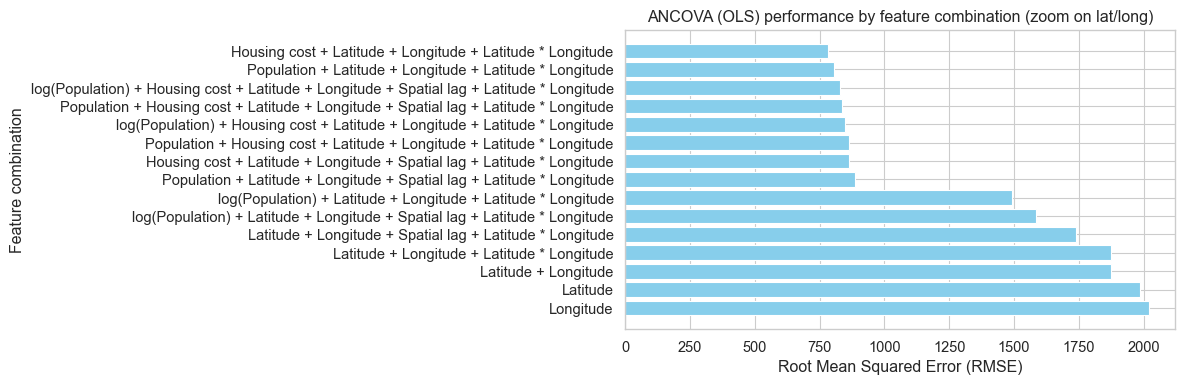

In [80]:
# Plotting ANCOVA RMSE results
plt.figure(figsize=(12, 4))
sorted_results = sorted(
    ancova_rmse_results.items(), key=lambda item: item[1], reverse=True
)
sorted_results = list(
    filter(
        lambda item: ("Latitude" in item[0][1] and "Longitude" in item[0][1])
        or ("Latitude" in item[0][0] and len(item[0][0]) == 1)
        or ("Longitude" in item[0][0] and len(item[0][0]) == 1)
        or ("Latitude" in item[0][0] and "Longitude" in item[0][0] and len(item[0][0]) == 2),
        sorted_results,
    )
)
combo_labels = [
    f"{' + '.join(combo)} + {' * '.join(cross)}" if len(cross) > 0 else ' + '.join(combo) for (combo, cross), _ in sorted_results
]
rmse_values = [r for _, r in sorted_results]
plt.barh(combo_labels, rmse_values, color="skyblue")
plt.xlabel("Root Mean Squared Error (RMSE)")
plt.ylabel("Feature combination")
plt.title("ANCOVA (OLS) performance by feature combination (zoom on lat/long)")
plt.tight_layout()
plt.show()

### 6.2 Model Comparison: ANCOVA vs. Random Forest

In [37]:
# ANCOVA (OLS Linear Model)
num_experiments = 100
total_rmse = 0
for i in range(num_experiments):
    X_train, X_test, y_train, y_test = train_test_split(final_df[["Year", "Age"] + FEATURES], y, test_size=0.2, random_state=i)
    formula = f'Q("Homeless count") ~ Year + C(Age) + {' + '.join([f'Q("{feature}")' for feature in FEATURES if feature != 'log(Population)'])}'
    ols_model = smf.ols(formula, data=final_df).fit()
    ols_preds = ols_model.predict(X_test)
    total_rmse += np.sqrt(mean_squared_error(y_test, ols_preds))
ols_rmse = total_rmse / num_experiments
print(f"\nANCOVA (OLS) Model RMSE: {ols_rmse:.2f}")
print(ols_model.summary())


ANCOVA (OLS) Model RMSE: 824.78
                             OLS Regression Results                            
Dep. Variable:     Q("Homeless count")   R-squared:                       0.841
Model:                             OLS   Adj. R-squared:                  0.839
Method:                  Least Squares   F-statistic:                     532.9
Date:                 Sun, 24 Aug 2025   Prob (F-statistic):               0.00
Time:                         15:00:33   Log-Likelihood:                -9960.2
No. Observations:                 1225   AIC:                         1.995e+04
Df Residuals:                     1212   BIC:                         2.001e+04
Df Model:                           12                                         
Covariance Type:             nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

In [38]:
# Random Forest
num_experiments = 100
total_rmse = 0
for i in range(num_experiments):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)
    rf_model = RandomForestRegressor(n_estimators=100, random_state=i)
    rf_model.fit(X_train, y_train)
    rf_preds = rf_model.predict(X_test)
    total_rmse += np.sqrt(mean_squared_error(y_test, rf_preds))
rf_rmse = total_rmse / num_experiments
print(f"Random Forest Model RMSE: {rf_rmse:.2f}")

Random Forest Model RMSE: 288.27


In [104]:
# Untrained model
num_experiments = 100
total_rmse = 0
for i in range(num_experiments):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)
    rf_model = RandomForestRegressor(n_estimators=100, random_state=i)
    rf_model.fit(X_train.head(1), y_train.head(1))
    rf_preds = rf_model.predict(X_test)
    total_rmse += np.sqrt(mean_squared_error(y_test, rf_preds))
rf_rmse = total_rmse / num_experiments
print(f"Untrained Random Forest Model RMSE: {rf_rmse:.2f}")

Untrained Random Forest Model RMSE: 2430.42


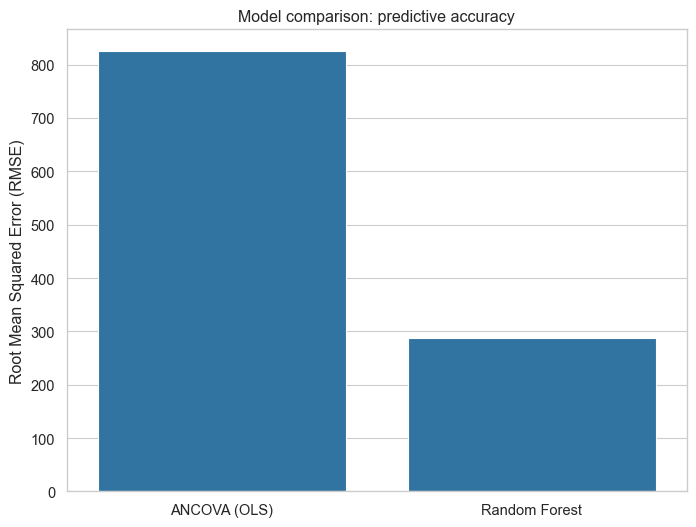

In [39]:
# Comparison Plot
plt.figure(figsize=(8, 6))
model_names = ['ANCOVA (OLS)', 'Random Forest']
rmse_scores = [ols_rmse, rf_rmse]
sns.barplot(x=model_names, y=rmse_scores)
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.title('Model comparison: predictive accuracy')
plt.show()

## 7. Final Model Analysis and Visualization

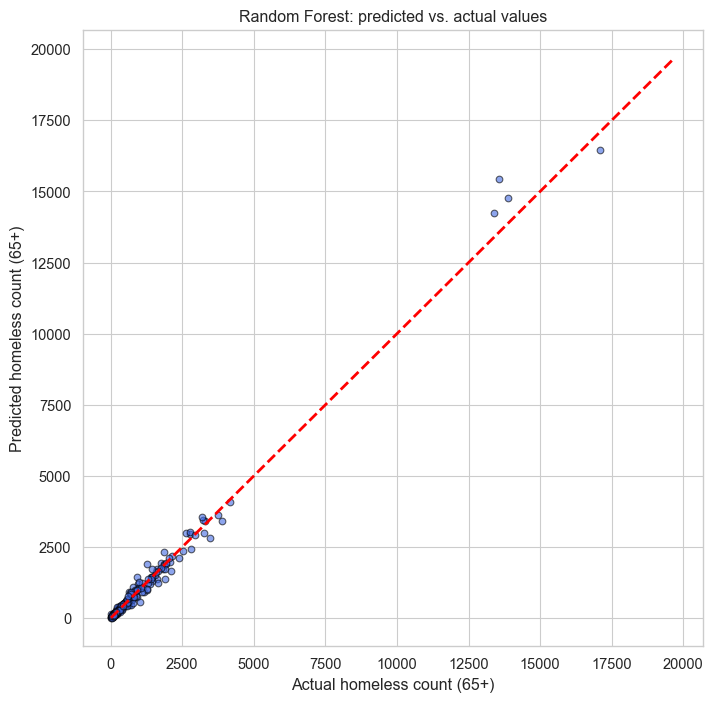

In [40]:
# --- Predicted vs. Actual Plot ---
plt.figure(figsize=(8, 8))
plt.scatter(y_test, rf_preds, alpha=0.6, edgecolors='k', c='royalblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--', color='red', lw=2)
plt.xlabel('Actual homeless count (65+)')
plt.ylabel('Predicted homeless count (65+)')
plt.title('Random Forest: predicted vs. actual values')
plt.grid(True)
plt.show()

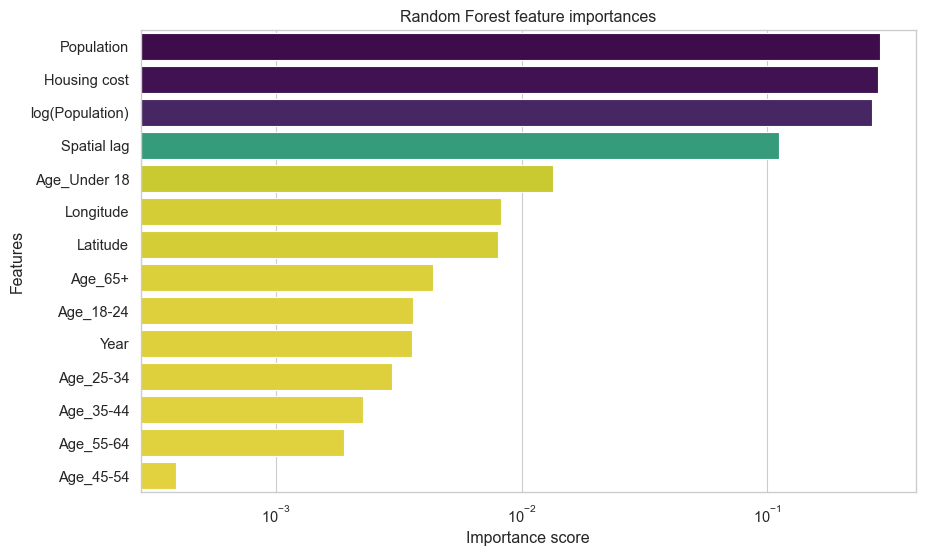

In [41]:
# --- Feature Importance Plot ---
feature_importances = pd.Series(rf_model.feature_importances_, index=rf_model.feature_names_in_).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index, hue=feature_importances, legend=False, palette='viridis_r')
plt.xscale('log')
plt.xlabel('Importance score')
plt.ylabel('Features')
plt.title('Random Forest feature importances')
plt.show()

## 8. Prediction Set with averaged population and housing cost

Using an average population of 892,077 for all CoCs.
Using an average housing cost of 874,481 for all CoCs.


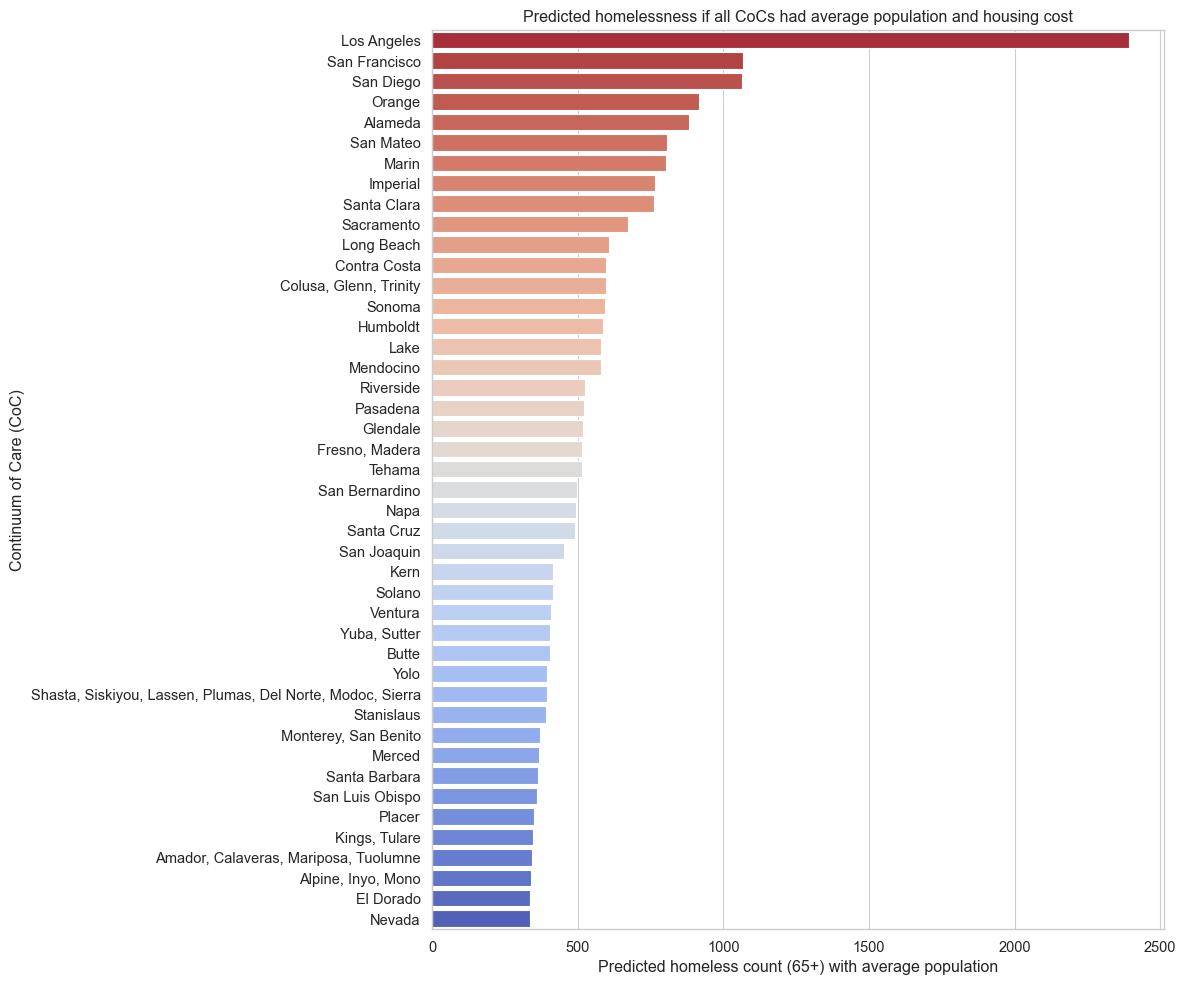

In [42]:
# This section creates a synthetic dataset where the population and housing cost
# of every CoC is set to the statewide average. This allows us to predict homelessness
# counts based on factors other than population size (e.g., housing costs, location).

# Create a copy of the final dataframe for our prediction set
prediction_set_df = pd.get_dummies(final_df, columns=['Age'], prefix='Age').set_index('CoC_Name').drop(columns='Homeless count')
log_pop = prediction_set_df.pop('log(Population)')
prediction_set_df.insert(2, 'log(Population)', log_pop)

# Calculate the average population and its log
avg_population = prediction_set_df['Population'].unique().mean()
# log_avg_population = np.log(avg_population + 1)
print(f"Using an average population of {avg_population:,.0f} for all CoCs.")

# Calculate the average housing cost
avg_housing_cost = prediction_set_df['Housing cost'].unique().mean()
print(f"Using an average housing cost of {avg_housing_cost:,.0f} for all CoCs.")

# Replace the population features with the average values
prediction_set_df['Population'] = avg_population
# prediction_set_df['log(Population)'] = log_avg_population
prediction_set_df['Housing cost'] = avg_housing_cost

# Select the same features the model was trained on
# X_prediction = prediction_set_df[FEATURES]
X_prediction = prediction_set_df

# for group in final_df.Age.unique():
#     X_prediction[f'Age_{group}'] = X[f'Age_{group}']
# X_prediction['Year'] = X['Year']
# X_prediction['Homeless count'] = X['Homeless count']
# X_prediction['Age_Invalid'] = X['Age_Invalid']
# X_prediction['Age_Unknown'] = X['Age_Unknown']

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Use the trained Random Forest model to predict on this new dataset
prediction_set_preds = rf_model.predict(X_prediction)

# Add predictions to the dataframe
prediction_set_df['Predicted_Homeless_Avg_Pop'] = prediction_set_preds

# --- Visualize the Prediction Set Results ---
# Sort for better visualization
sorted_predictions = prediction_set_df[(prediction_set_df.Year == 2023) & (prediction_set_df['Age_65+'])].sort_values('Predicted_Homeless_Avg_Pop', ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(x='Predicted_Homeless_Avg_Pop', y=sorted_predictions.index, data=sorted_predictions, palette='coolwarm_r', hue=sorted_predictions.index, dodge=False, legend=False)
plt.xlabel('Predicted homeless count (65+) with average population')
plt.ylabel('Continuum of Care (CoC)')
plt.title('Predicted homelessness if all CoCs had average population and housing cost')
plt.tight_layout()
plt.show()

In [43]:
def plot_metric_on_map(
    metric_df, coc_geodata, column_name, title, cmap="viridis", label=None
):
    """
    Generates a choropleth map of a specified metric for California CoCs.

    Args:
        metric_df (pd.DataFrame): DataFrame containing the metric data with CoC names as index.
        coc_geodata (gpd.GeoDataFrame): GeoDataFrame with CoC geometries and a 'CoC_Name' column.
        column_name (str): The name of the column in metric_df to plot.
        title (str): The title for the map.
        cmap (str, optional): The colormap to use. Defaults to 'viridis'.
        label (str, optional): The label for the color bar. If None, uses column_name.
    """
    if label is None:
        label = column_name

    # Merge the metric data with the geospatial data
    map_data = coc_geodata.merge(
        metric_df[[column_name]],
        left_on="CoC_Name",
        right_index=True,
        how="inner",
    )

    # Create the plot
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    map_data.plot(
        column=column_name,
        ax=ax,
        legend=True,
        cmap=cmap,
        legend_kwds={
            "label": label,
            "shrink": 0.8,
            # "orientation": "horizontal",
        },
    )

    ax.set_title(title, fontdict={"fontsize": "16", "fontweight": "3"})
    ax.set_axis_off()
    plt.show()

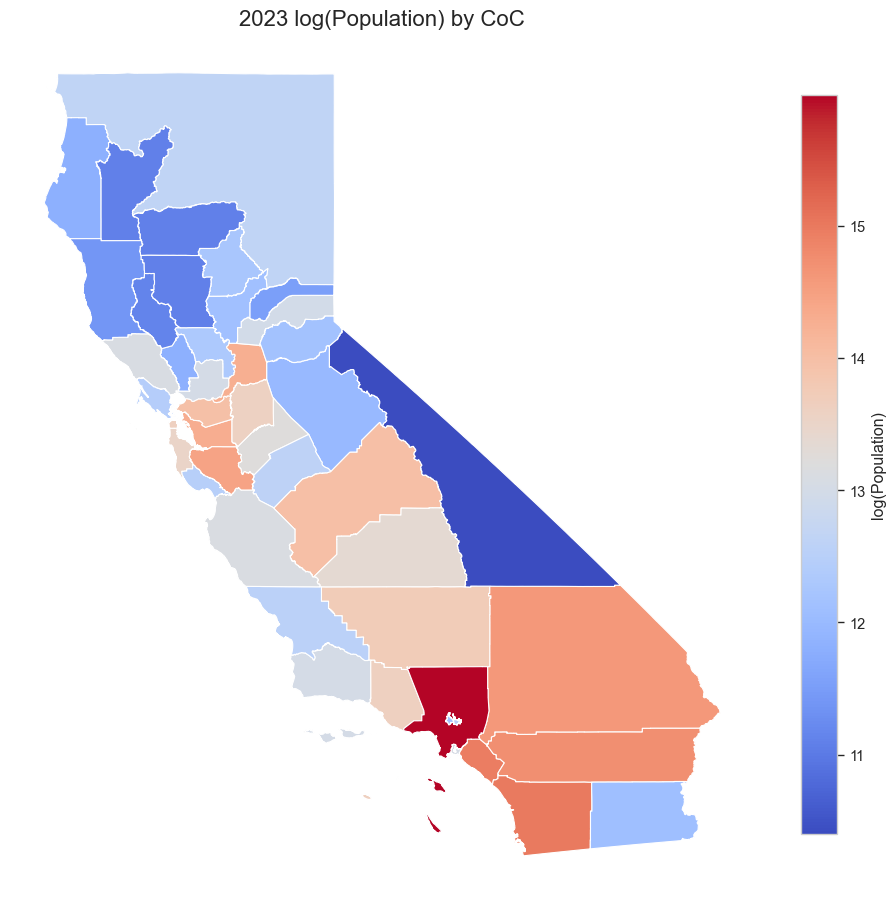

In [44]:
plot_metric_on_map(
    final_df[(final_df.Year==2023)&(final_df.Age=='65+')].set_index('CoC_Name'),
    coc_gdf,
    column_name="log(Population)",
    title="2023 log(Population) by CoC",
    cmap="coolwarm",
)

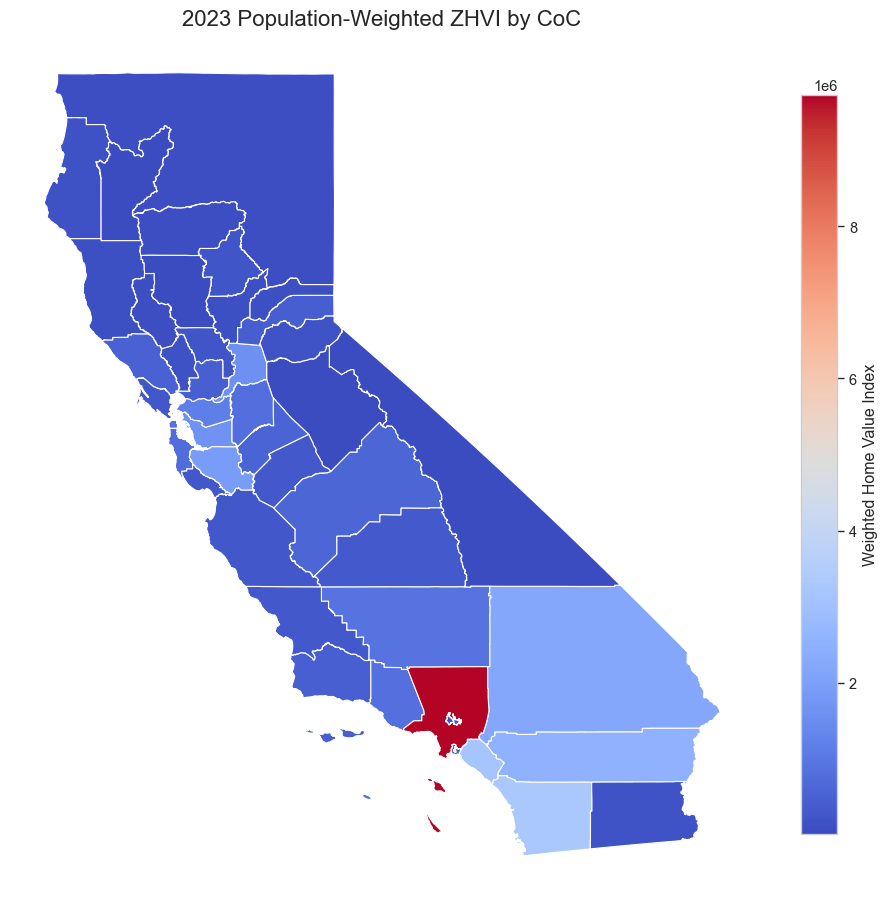

In [45]:
plot_metric_on_map(
    final_df[(final_df.Year==2023)&(final_df.Age=='65+')].set_index('CoC_Name'),
    coc_gdf,
    column_name="Housing cost",
    title="2023 Population-Weighted ZHVI by CoC",
    cmap="coolwarm",
    label="Weighted Home Value Index",
)

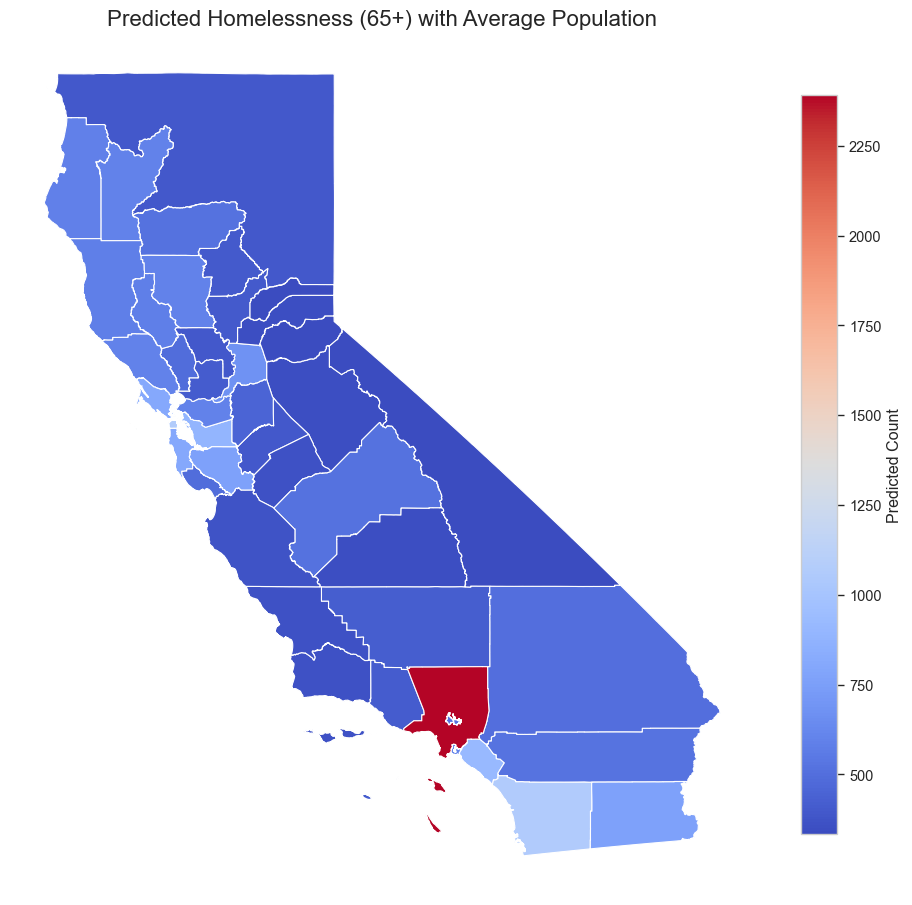

In [46]:
plot_metric_on_map(
    prediction_set_df[(prediction_set_df.Year==2023)&(prediction_set_df['Age_65+'])],
    coc_gdf,
    column_name="Predicted_Homeless_Avg_Pop",
    title="Predicted Homelessness (65+) with Average Population",
    cmap="coolwarm",
    label="Predicted Count",
)